In this tutorial, we will load the timeseries for one patient from [Minervina et al 2021](https://elifesciences.org/articles/63502). 

The data used can be downloaded from https://zenodo.org/records/4065547 > `beta.zip > PBMC`. The example is run using `M_[]_F1_beta.txt.gz` samples. Download these samples and place them in the `test_data/input` directory.

We also generate a `metadata.txt` file with sample name and timepoint information and place it in the same directory. You can see the metadata file in `test_data/input/`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

from clonesearch.load_data import load_data
from clonesearch.plotting.noise_profile import plot_noise_profile
from clonesearch.utils.get_params import get_sigma_and_b, calc_diffs, make_df, var_btn_tps
from clonesearch.utils.normalisation_functions import g_of_f
from clonesearch.utils.gaussian_outliers import find_gaussian_outliers
from clonesearch.plotting.outlier_definition import plot_pca, plot_R_and_fit

#### 1. Load TCR sequencing data

In [2]:
# load metadata
metadata = pd.read_csv('../test_data/input/metadata.txt')
metadata

,sample,timepoint
0,M_15_F1_beta.txt.gz,15
1,M_30_F1_beta.txt.gz,30
2,M_37_F1_beta.txt.gz,37
3,M_45_F1_beta.txt.gz,45
4,M_85_F1_beta.txt.gz,85
5,M_F1_2018_beta.txt.gz,-10
6,M_F1_2019_beta.txt.gz,-5


We use CloneSearch's inbuilt loading function to prepare the data, but custom approaches can also be used.
First we have to define which columns in the file we are going to load.
We will use:
1. CDR3 column, V and J columns to define the clone - clonalSequence, bestVgene, bestJgene
2. Clone counts column - cloneCount
3. CDR3aa sequence column, to define productive sequences - aaSeqCDR3

In [3]:
columns = ['clonalSequence', 'bestVGene', 'bestJGene', 'cloneCount', 'aaSeqCDR3']
clone_id_columns = ['clonalSequence', 'bestVGene', 'bestJGene'] # which columns define the clone id

sample_order = metadata.sort_values(by = 'timepoint')['sample'].tolist()

tcr_data = load_data(
    input_path='../test_data/input/',
    output_path='../test_data/output/',
    delimiter='tab',
    columns=columns,
    clone_id_cols=clone_id_columns,
    sample_list=sample_order
)

All data loaded and formatted into counts per TCR.


#### 2. Run CloneSearch

Instead of running CloneSearch in a single command, we will run all the internal steps to look at the diagnostic plots.

In [4]:
# set up all the information we need
counts = tcr_data.values
all_clones = tcr_data.index.tolist()
N_r = counts.sum(axis=0) # sequencing depth
# mapping of sample names to timepoints
timepoint_dictionary = dict(zip(metadata['sample'], metadata['timepoint']))


In [5]:
# only retain clones that are present with count >=3 at more than one timepoint
mask = (counts > 2).sum(axis=1) > 1 

freqs_all = counts/N_r
freqs_qc = freqs_all[mask,:]
qc_clones = np.array(all_clones)[mask]

freq_info = pd.DataFrame(freqs_qc, index = qc_clones, columns=sample_order)

First, we need to fit the noise paramters

In [6]:
# calculate fluctuations

avgs, dt, f, percentiles, N = calc_diffs(var_btn_tps, freq_info, 
                                         sample_order, timepoint_dictionary, 
                                         use_percentiles=True, 
                                         perc_step=10, min_perc=0, dt_min = 0)

N_df = make_df(N, 'N')
avgs_df = make_df(avgs, 'avgs')
dt_df = make_df(dt, 'dt')
freqs_df = make_df(f, 'freqs')

avgs_df = pd.merge(avgs_df, N_df)
avgs_dt = pd.merge(avgs_df, dt_df)
avgs_dt_freqs = pd.merge(avgs_dt, freqs_df)
avgs_dt_freqs['percentiles'] = avgs_dt_freqs['p1'] + '-' + avgs_dt_freqs['p2']

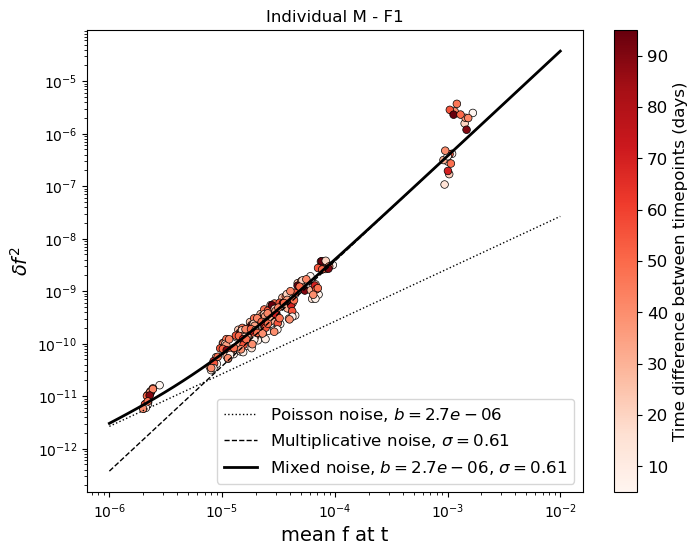

(np.float64(0.6113426849785193), np.float64(2.6628107223058414e-06))

In [7]:
plot_noise_profile(avgs_dt_freqs, show = True, title='Individual M - F1', xlims = (-6,-2))

In [8]:
sigma, fit_b = get_sigma_and_b(freq_info, sample_order, timepoint_dictionary)
beta_factor = N_r*fit_b
# assume that the noise factor is constant across samples,
# and that the actual noise will depend on sample size
# so, we want to take beta to be constant
beta_factor = [np.mean(beta_factor)]*len(beta_factor)
print(f'sigma = {sigma}, beta = {beta_factor[0]}')

# now transform using g(f)
X_transformed = g_of_f(freqs_qc, N_r, sigma, beta_factor)
X_transformed_norm = X_transformed - X_transformed.max(axis=1).reshape(-1, 1)

sigma = 0.6113426849785193, beta = 4.131617497131275


In [9]:
# calculate the PCA and the outliers from the PCA
pca = PCA(whiten = True)
pca_fit = pca.fit_transform(X_transformed_norm)
R, outlier_vector, R_thresh = find_gaussian_outliers(pca_fit, use_FDR = True, statistical_threshold = 0.05)
print('Number of outliers: ', sum(outlier_vector))

Number of outliers:  1436


/Users/milighm/Desktop/github-clones/CloneSearch/clonesearch/utils/gaussian_outliers.py:56: RuntimeWarning: invalid value encountered in divide
  idx = np.where((1-theory)/(1-ecdf_real.cdf.probabilities) < fdr)[0][0]


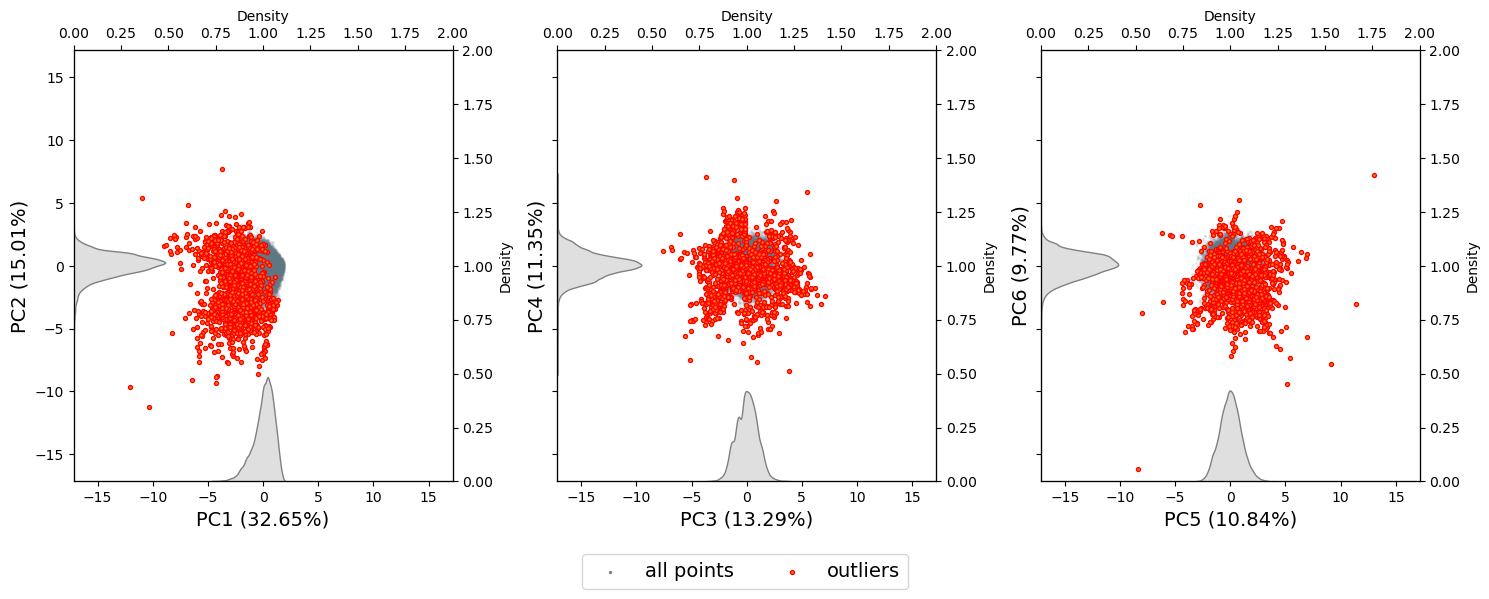

In [10]:
plot_pca(pca_fit, pca.explained_variance_ratio_, 
         outlier_vector, R_thresh, 
         show_density=True, num_PCs = 6)

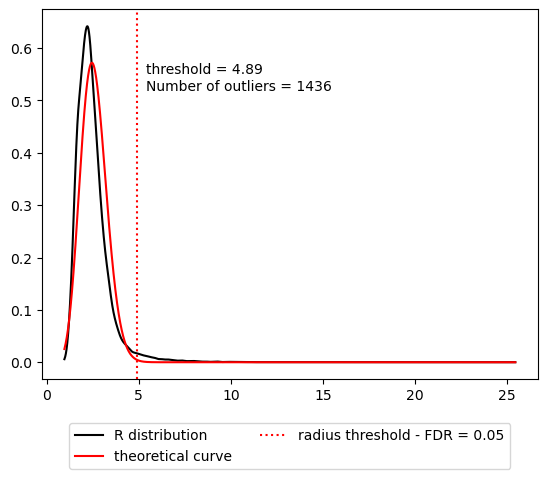

In [11]:
plot_R_and_fit(R, R_thresh, 
               n_dims = len(sample_order), 
               stat_thresh=0.05, show = True)

Once you have the list of outliers, you can plot the clustermap and the trajectories as in `tutorial.ipynb`.